# **1-Load Needed Libraries and Preproccessing**

---



---



In [1]:
import kagglehub

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

!pip install lime
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)
import shap

path = kagglehub.dataset_download("brandao/diabetes")
print("Path to dataset files:", path)

import os
file_path = os.path.join(path, [f for f in os.listdir(path) if f.endswith('.csv')][0])
df = pd.read_csv(file_path)

print("Original dataset shape:", df.shape)
df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=14e8324b9fe8c27b7c52e25e3745c8298418c02a70ae10a1244f804b9b1299de
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes
Original dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [2]:
df["weight"].value_counts()

,count
weight,
?,98569
[75-100),1336
[50-75),897
[100-125),625
[125-150),145
[25-50),97
[0-25),48
[150-175),35
[175-200),11


In [3]:
df["payer_code"].value_counts()

,count
payer_code,
?,40256
MC,32439
HM,6274
SP,5007
BC,4655
MD,3532
CP,2533
UN,2448
CM,1937


In [4]:

df.isnull().sum()


,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [5]:
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [6]:
df.shape

(101766, 50)

In [7]:
df = df[df['race'] != '?']

In [8]:
df = df[df['gender'] != 'Unknown/Invalid']

Key discharge_disposition_id Mappings
The dataset uses 29 distinct values, with the most important mappings including:

1: Discharged to Home

3: Discharged/transferred to Skilled Nursing Facility (SNF)

6: Discharged/transferred to home with home health service

11, 19, 20, 21: Expired (Patient deceased)

18: Null/Not Mapped

In [9]:
def map_discharge(x):
    if x == 1:
        return "Home"
    elif x in [3, 6]:
        return "Care"
    elif x == 2:
        return "Transfer"
    elif x in [11, 19, 20, 21]:
        return "Death"
    elif x in [13, 14]:
        return "Hospice"
    elif x == 18:
        return "Unknown"
    else:
        return "Other"

df['discharge_group'] = df['discharge_disposition_id'].apply(map_discharge)

In [10]:
df = df[df['discharge_group'] != 'Unknown']

Column: metformin-rosiglitazone -------------------------------------------------- metformin-rosiglitazone

 No 95819

zero variance feature

In [11]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'discharge_group'],
      dtype='object')

In [12]:
df_c = df.drop(columns=[
    'discharge_disposition_id',
    'metformin-pioglitazone',
    'glyburide-metformin',
    'glimepiride-pioglitazone',
    'encounter_id',
    'patient_nbr',
    'weight',
    'max_glu_serum',
    'A1Cresult',
    'payer_code',
    'medical_specialty',
    'glipizide-metformin',
    'metformin-rosiglitazone',
    'examide',
    'citoglipton',
    'acetohexamide',
    'troglitazone',
    'tolbutamide',
    'tolazamide',
    'chlorpropamide', 'miglitol', 'acarbose',
    'nateglinide', 'repaglinide'
])

In [13]:
df_c.shape

(95819, 27)

In [14]:
def map_icd9(code):
    try:
        c = str(code).strip()
        if c.startswith('V'): return 'Supplementary'
        if c.startswith('E'): return 'External_Causes'
        n = float(c)
        if n < 140:  return 'Infectious'
        if n < 240:  return 'Neoplasms'
        if n < 280:  return 'Endocrine_Diabetes'
        if n < 290:  return 'Blood'
        if n < 320:  return 'Mental'
        if n < 360:  return 'Nervous_System'
        if n < 390:  return 'Sensory'
        if n < 460:  return 'Circulatory'       # 428=heart failure, 410=MI
        if n < 520:  return 'Respiratory'       # 486=pneumonia
        if n < 580:  return 'Digestive'
        if n < 630:  return 'Genitourinary'
        if n < 680:  return 'Pregnancy'
        if n < 710:  return 'Skin'
        if n < 740:  return 'Musculoskeletal'
        if n < 760:  return 'Congenital'
        if n < 780:  return 'Perinatal'
        if n < 800:  return 'Symptoms'
        return 'Injury'
    except:
        return 'Other'

df_c['diag_1'] = df_c['diag_1'].apply(map_icd9)
df_c['diag_2'] = df_c['diag_2'].apply(map_icd9)
df_c['diag_3'] = df_c['diag_3'].apply(map_icd9)

In [15]:
df_c.isnull().sum().sum()

np.int64(0)

In [16]:
df_c.duplicated().sum()

np.int64(1)

In [17]:
df_c.drop_duplicates( inplace = True)

In [18]:
age_map = {
    '[0-10)':0, '[10-20)':1, '[20-30)':2, '[30-40)':3,
    '[40-50)':4, '[50-60)':5, '[60-70)':6, '[70-80)':7,
    '[80-90)':8, '[90-100)':9
}
df_c['age'] = df_c['age'].map(age_map)

Is the patient:

0 → Will not return
1 → Will return after a long time
2 → Will return soon (dangerous)

In [19]:
readmit_map = {'NO': 0, '>30': 1, '<30': 2}
df_c['readmitted'] = df_c['readmitted'].map(readmit_map)

In [20]:
df_c.columns

Index(['race', 'gender', 'age', 'admission_type_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
       'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted',
       'discharge_group'],
      dtype='object')

In [21]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95818 entries, 0 to 101765
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   race                 95818 non-null  object
 1   gender               95818 non-null  object
 2   age                  95818 non-null  int64 
 3   admission_type_id    95818 non-null  int64 
 4   admission_source_id  95818 non-null  int64 
 5   time_in_hospital     95818 non-null  int64 
 6   num_lab_procedures   95818 non-null  int64 
 7   num_procedures       95818 non-null  int64 
 8   num_medications      95818 non-null  int64 
 9   number_outpatient    95818 non-null  int64 
 10  number_emergency     95818 non-null  int64 
 11  number_inpatient     95818 non-null  int64 
 12  diag_1               95818 non-null  object
 13  diag_2               95818 non-null  object
 14  diag_3               95818 non-null  object
 15  number_diagnoses     95818 non-null  int64 
 16  metformi

In [22]:
df_num = df_c.select_dtypes(include=np.number)


#**Step 2: EDA**
----------------------------------------------------------------------------------------------
------------------------------------------------------------------------

In [23]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

/tmp/ipykernel_15707/3926361904.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_c, x='readmitted', palette='spring')
/tmp/ipykernel_15707/3926361904.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Readmit', '>30 Days', '<30 Days'])


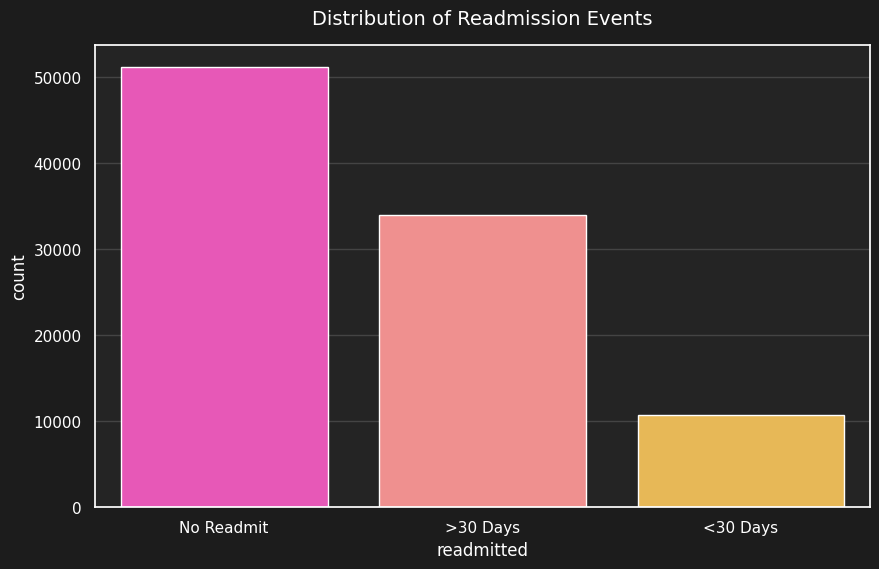

In [24]:

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df_c, x='readmitted', palette='spring')

plt.title('Distribution of Readmission Events', color='white', fontsize=14, pad=15)
ax.set_xticklabels(['No Readmit', '>30 Days', '<30 Days'])

plt.show()

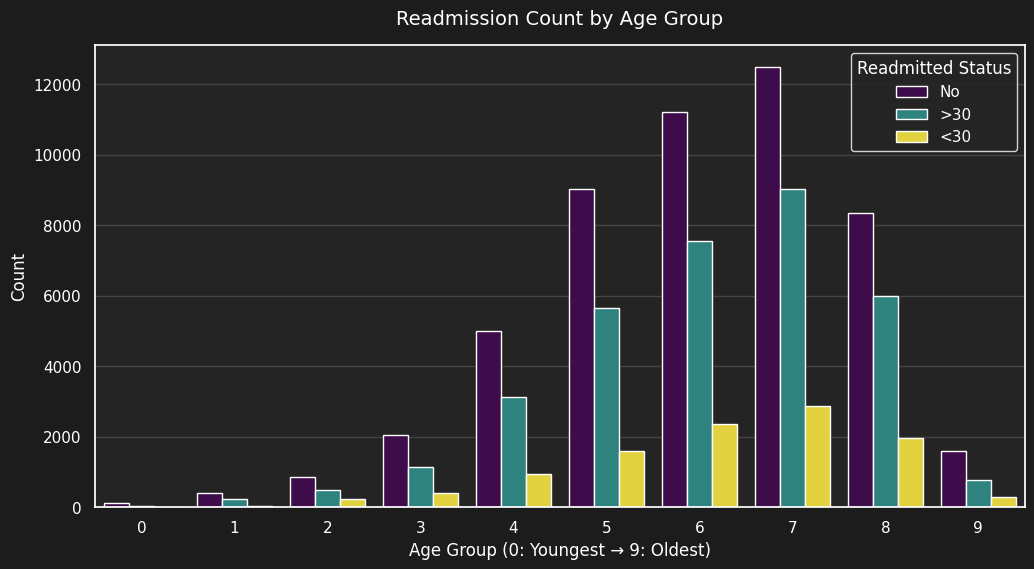

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df_c, x='age', hue='readmitted', palette='viridis')

plt.title('Readmission Count by Age Group', color='white', fontsize=14, pad=15)
plt.xlabel('Age Group (0: Youngest → 9: Oldest)', color='white')
plt.ylabel('Count', color='white')

legend = plt.legend(title='Readmitted Status', labels=['No', '>30', '<30'],
                    facecolor='#242424', edgecolor='white')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')
plt.show()

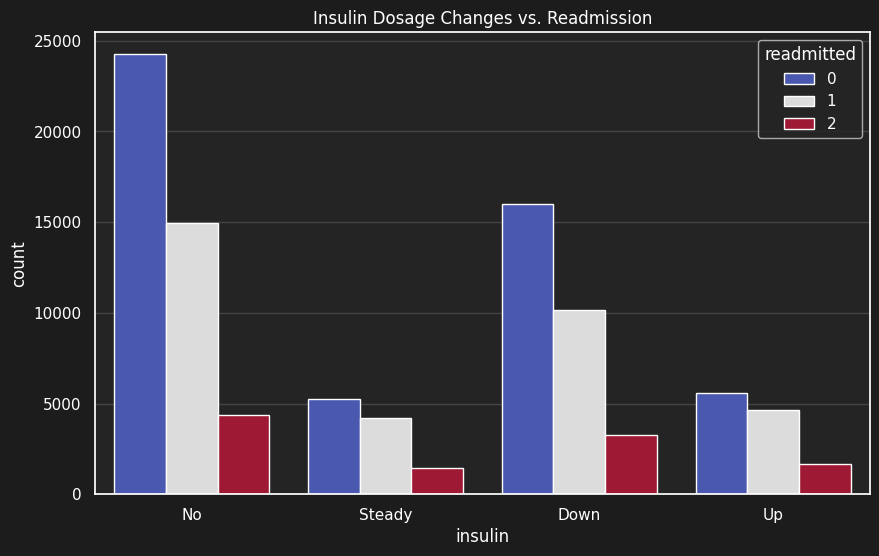

In [26]:

plt.figure(figsize=(10, 6))
sns.countplot(data=df_c, x='insulin', hue='readmitted', palette='coolwarm')
plt.title('Insulin Dosage Changes vs. Readmission')
plt.xticks([0, 1, 2, 3], ['No', 'Steady', 'Down', 'Up'])
plt.show()

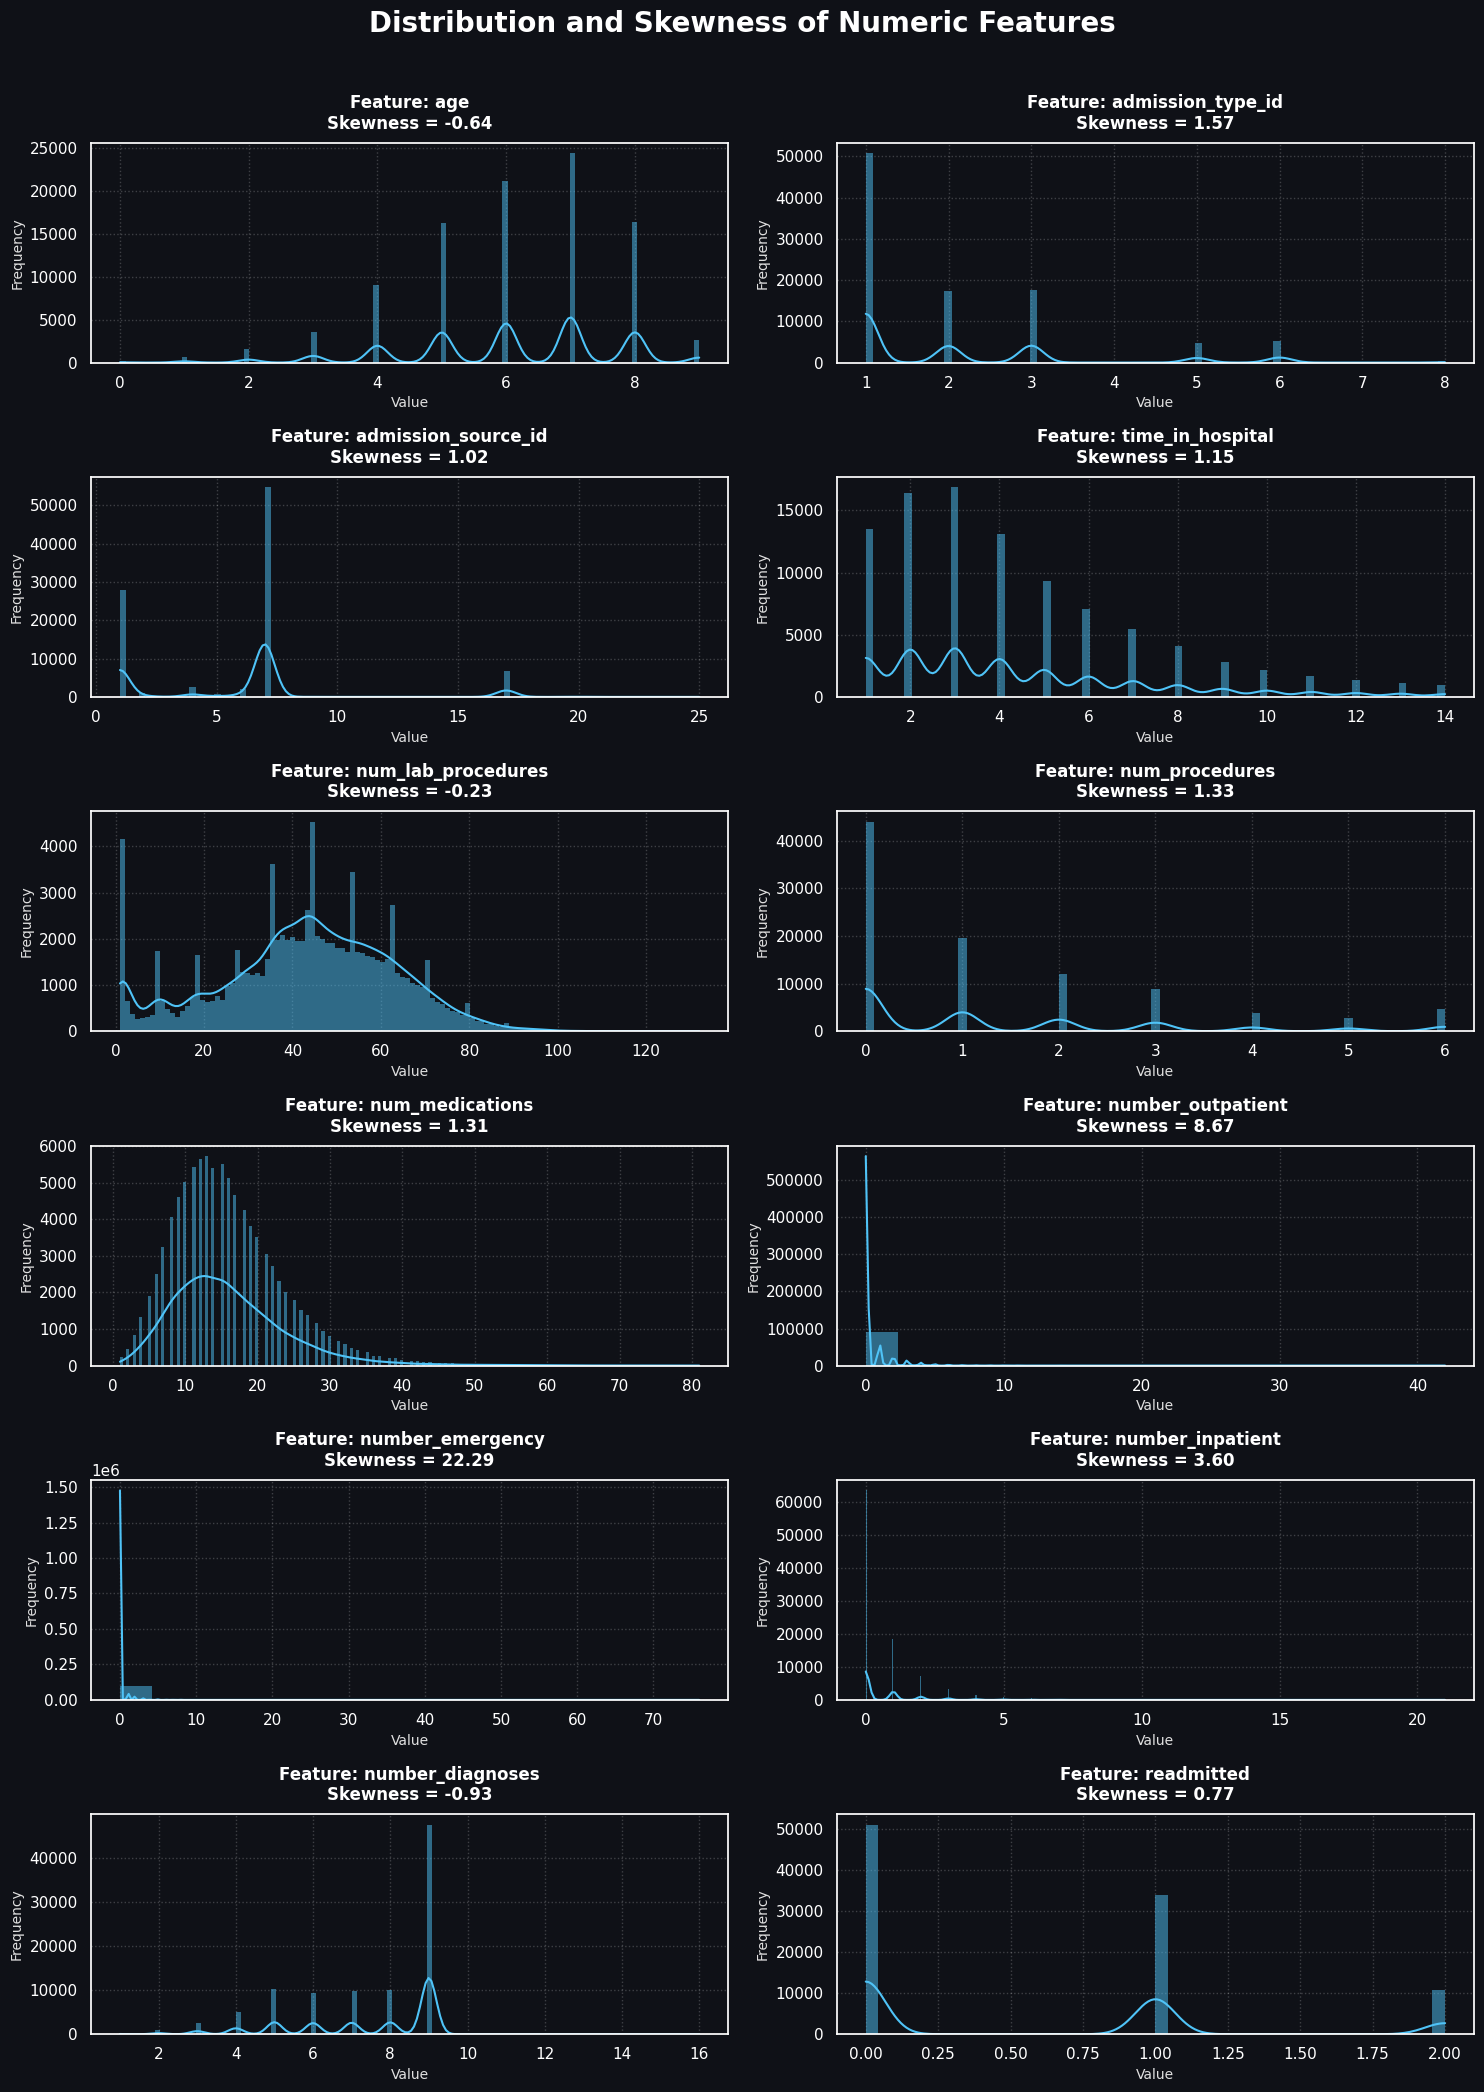

In [27]:

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 22))
fig.set_facecolor('#0f1117')

axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    if i >= len(axes_flat):
        break
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')

    skew_val = df_c[col].skew()

    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)

    ax.set_title(f"Feature: {col}\nSkewness = {skew_val:.2f}",
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel("Value", fontsize=10, color='#e0e0e0')
    ax.set_ylabel("Frequency", fontsize=10, color='#e0e0e0')

    ax.grid(True, linestyle=':', alpha=0.2, color='white')

    ax.tick_params(colors='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Distribution and Skewness of Numeric Features", color='white', fontsize=20, fontweight='bold')

plt.show()

In [28]:

cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient', 'num_medications', 'time_in_hospital']

for col in cols_to_fix:
    df_c[col] = np.log1p(df_c[col])

print("Skewness after Log Transformation:")
print(df_c[cols_to_fix].skew())

Skewness after Log Transformation:
number_emergency     3.546373
number_outpatient    2.668303
number_inpatient     1.433748
num_medications     -0.499344
time_in_hospital     0.111122
dtype: float64


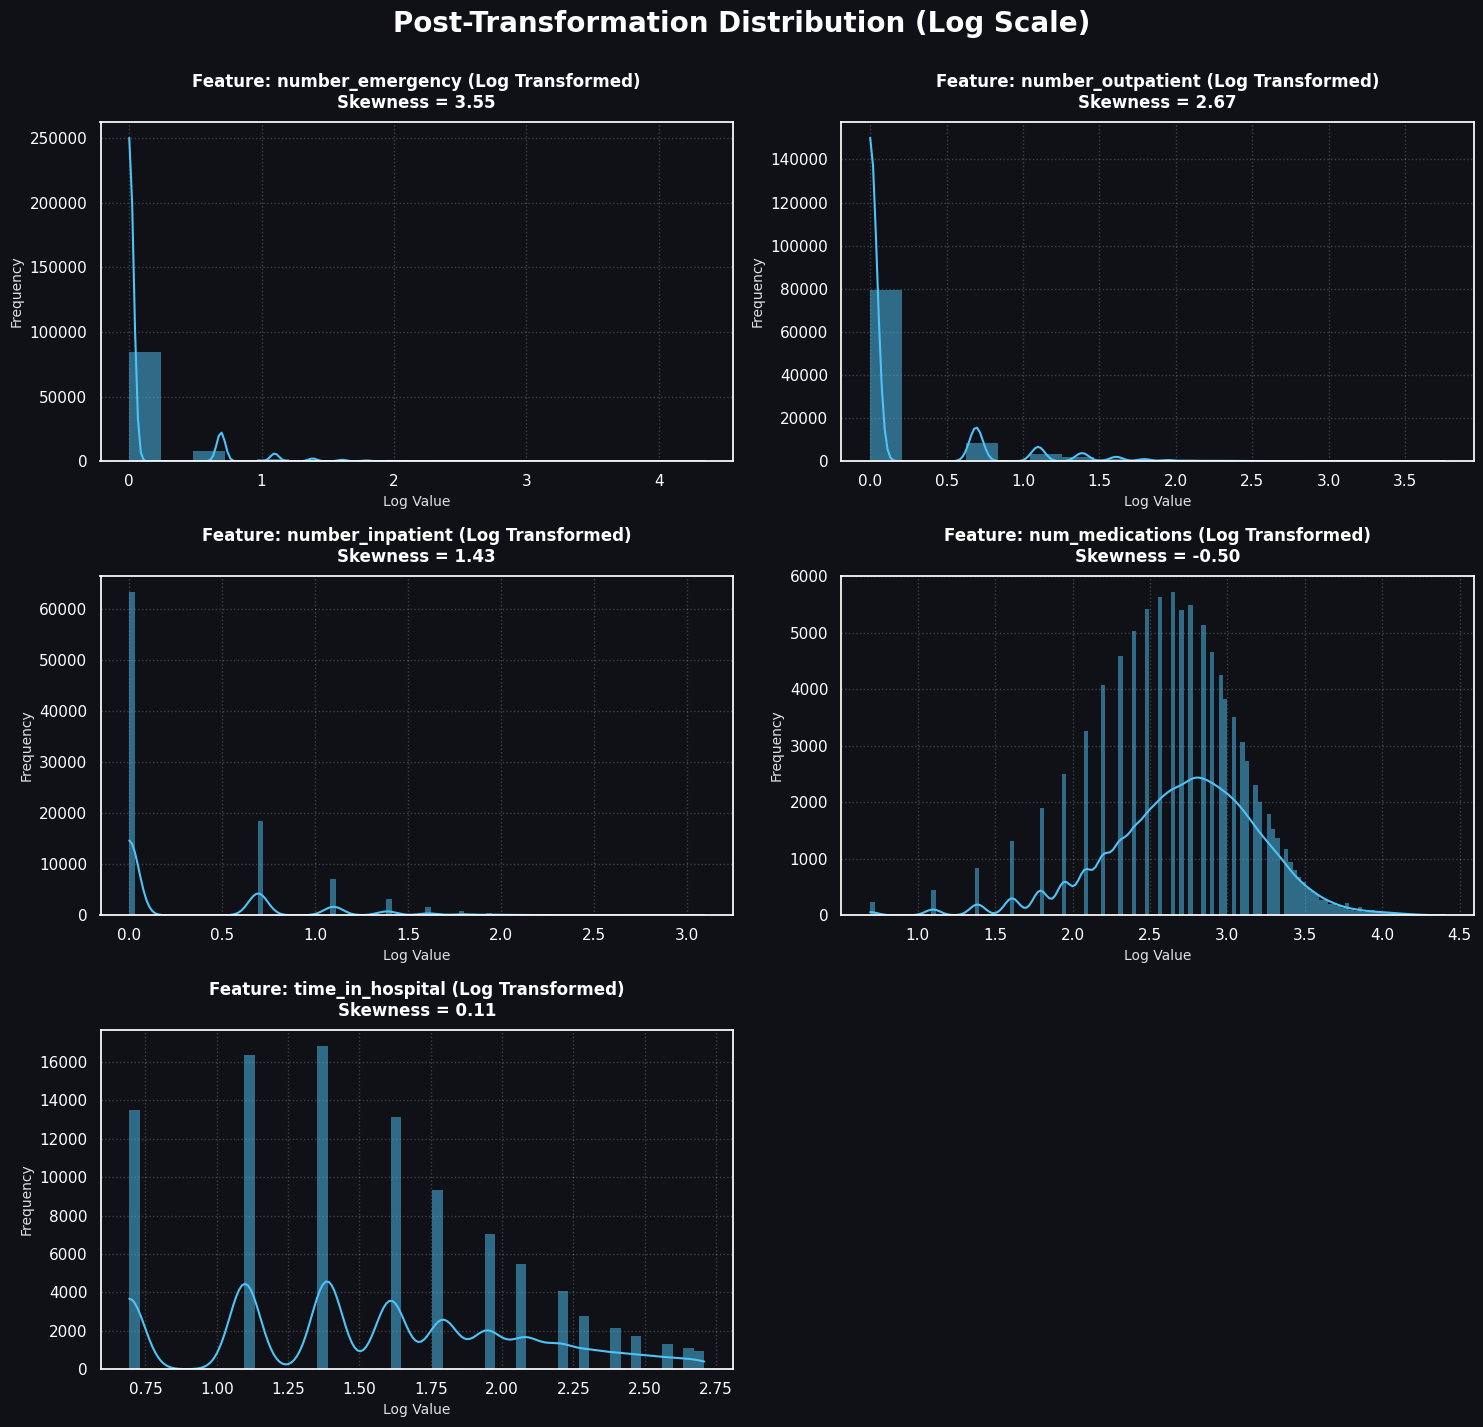

In [29]:


cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient', 'num_medications', 'time_in_hospital']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
fig.set_facecolor('#0f1117')

axes_flat = axes.flatten()

for i, col in enumerate(cols_to_fix):
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')

    skew_val = df_c[col].skew()

    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)

    ax.set_title(f"Feature: {col} (Log Transformed)\nSkewness = {skew_val:.2f}",
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel("Log Value", fontsize=10, color='#e0e0e0')
    ax.set_ylabel("Frequency", fontsize=10, color='#e0e0e0')
    ax.grid(True, linestyle=':', alpha=0.2, color='white')
    ax.tick_params(colors='white')

axes_flat[5].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Post-Transformation Distribution (Log Scale)", color='white', fontsize=20, fontweight='bold')

plt.show()

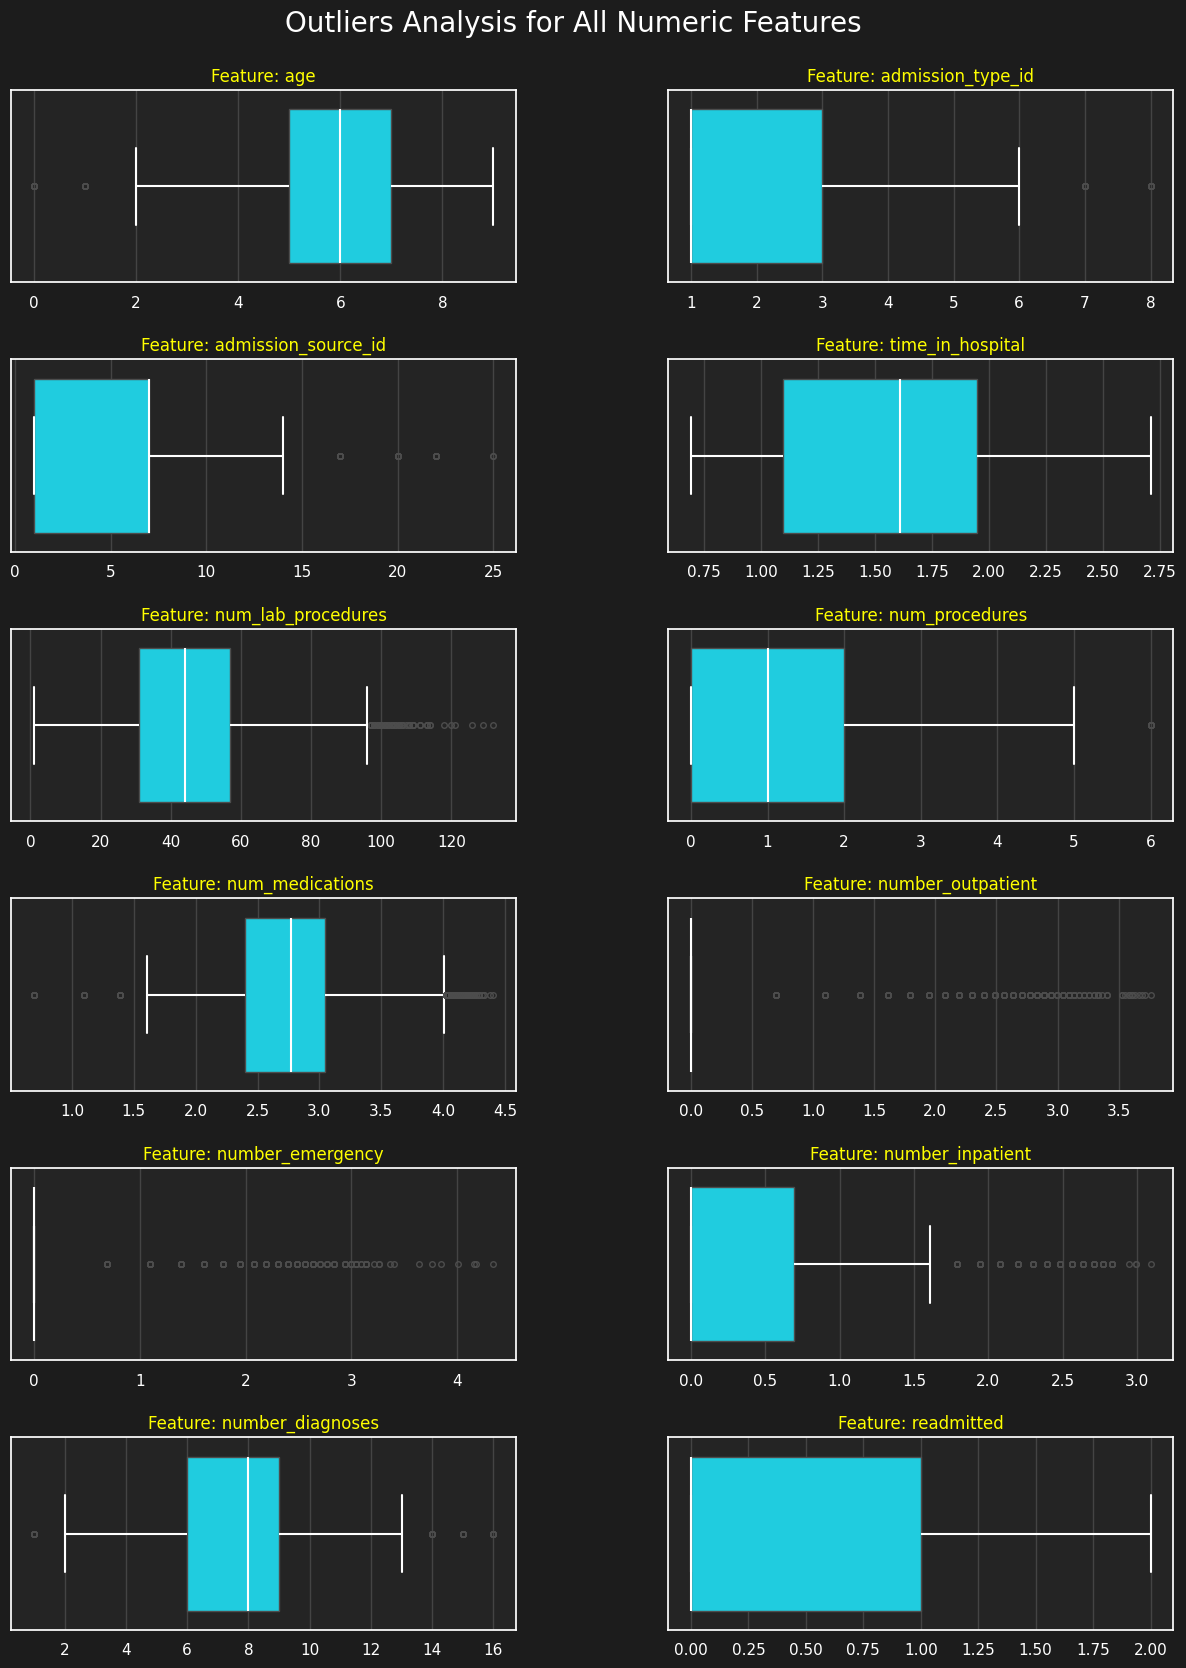

In [30]:

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})



fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Outliers Analysis for All Numeric Features', color='white', fontsize=20, y=0.92)

axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    ax = axes_flat[i]

    sns.boxplot(x=df_c[col], ax=ax, color='#00e5ff', fliersize=4)

    plt.setp(ax.artists, edgecolor="white", linewidth=1.5)
    plt.setp(ax.lines, color="white", linewidth=1.5)

    ax.set_title(f'Feature: {col}', color='yellow', fontsize=12)
    ax.set_xlabel('')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.show()

In [31]:


print(f"{'Feature':<25} | {'Outliers Count':<15} | {'Percentage':<10}")
print("-" * 55)

total_rows = len(df_c)

for col in df_num:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_c[(df_c[col] < lower_bound) | (df_c[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / total_rows) * 100

    print(f"{col:<25} | {count:<15} | {percentage:.2f}%")

Feature                   | Outliers Count  | Percentage
-------------------------------------------------------
age                       | 838             | 0.87%
admission_type_id         | 337             | 0.35%
admission_source_id       | 6866            | 7.17%
time_in_hospital          | 0               | 0.00%
num_lab_procedures        | 142             | 0.15%
num_procedures            | 4582            | 4.78%
num_medications           | 1770            | 1.85%
number_outpatient         | 16389           | 17.10%
number_emergency          | 11272           | 11.76%
number_inpatient          | 1960            | 2.05%
number_diagnoses          | 261             | 0.27%
readmitted                | 0               | 0.00%


In [32]:
safe_cols_to_clean = ['age', 'num_lab_procedures', 'num_medications', 'number_diagnoses', 'time_in_hospital']

print(f"Original shape: {df_c.shape}")

for col in safe_cols_to_clean:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_c = df_c[(df_c[col] >= lower_bound) & (df_c[col] <= upper_bound)]

print(f"Fixed shape: {df_c.shape}")



Original shape: (95818, 27)
Fixed shape: (91572, 27)


In [33]:


print(f"{'Feature':<25} | {'Outliers Count':<15} | {'Percentage':<10}")
print("-" * 55)

total_rows = len(df_c)

for col in df_num:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_c[(df_c[col] < lower_bound) | (df_c[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / total_rows) * 100

    print(f"{col:<25} | {count:<15} | {percentage:.2f}%")

Feature                   | Outliers Count  | Percentage
-------------------------------------------------------
age                       | 0               | 0.00%
admission_type_id         | 324             | 0.35%
admission_source_id       | 6667            | 7.28%
time_in_hospital          | 0               | 0.00%
num_lab_procedures        | 0               | 0.00%
num_procedures            | 4217            | 4.61%
num_medications           | 0               | 0.00%
number_outpatient         | 15944           | 17.41%
number_emergency          | 10940           | 11.95%
number_inpatient          | 1914            | 2.09%
number_diagnoses          | 0               | 0.00%
readmitted                | 0               | 0.00%


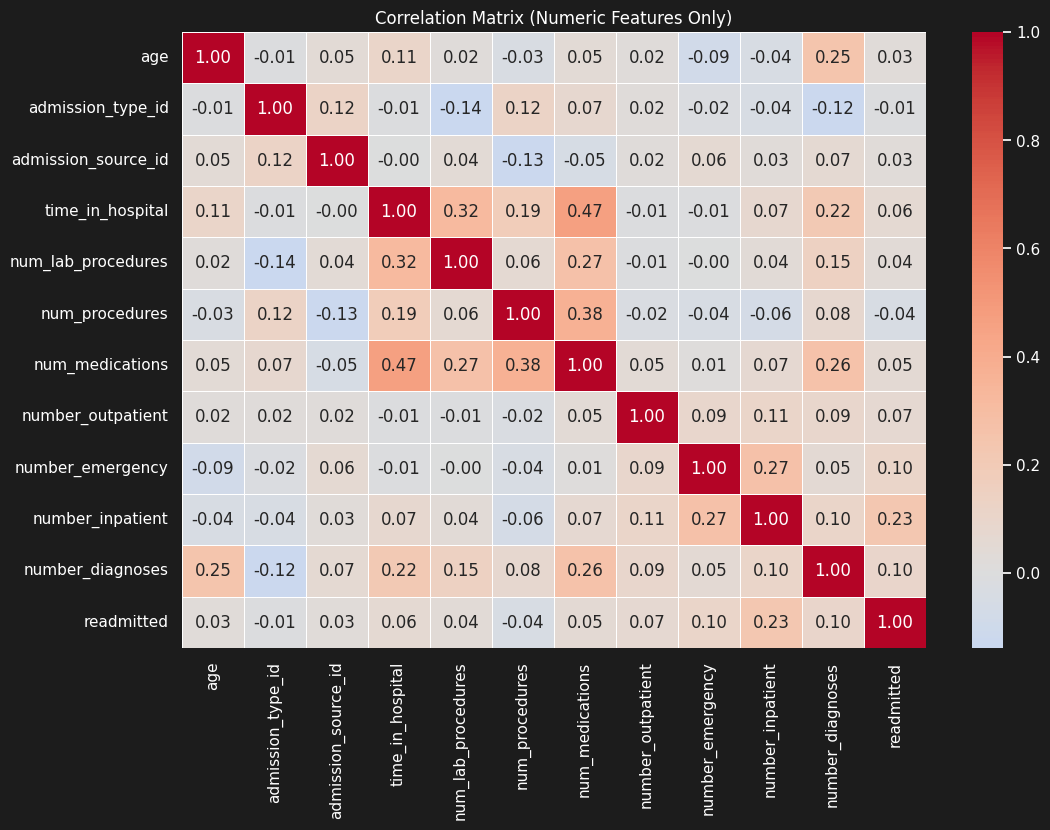

readmitted             1.000000
number_inpatient       0.233497
number_emergency       0.104288
number_diagnoses       0.100961
number_outpatient      0.067485
time_in_hospital       0.057634
num_medications        0.054058
num_lab_procedures     0.036428
age                    0.031047
admission_source_id    0.028534
admission_type_id     -0.008632
num_procedures        -0.036341
Name: readmitted, dtype: float64


In [34]:

corr_matrix = df_num.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

corr_with_target = corr_matrix['readmitted'].sort_values(ascending=False)
print(corr_with_target)
#need to drop  admission_type_id  &&  num_procedures

#**Feature Engineering/Selection**
----------------------------------------------------------------------------------------
--------------------------------------------------------------------


In [35]:
df_c = df_c.drop(columns=['admission_type_id', 'num_procedures'])

In [36]:
cat_cols = ['race', 'gender', 'change', 'diabetesMed',
            'discharge_group', 'diag_1', 'diag_2', 'diag_3']

df_c = pd.get_dummies(df_c, columns=cat_cols, drop_first=True)

In [37]:
df_c['admission_source_id'] = df_c['admission_source_id'].astype(str)
df_c = pd.get_dummies(df_c, columns=['admission_source_id'], drop_first=True)

In [38]:
drop_cols = [
    # admission_source_id
    'admission_source_id_8',  # 16 rows
    'admission_source_id_9',  # 54 rows
    'admission_source_id_10', # 7 rows
    'admission_source_id_11', # 2 rows
    'admission_source_id_13', # 1 row
    'admission_source_id_14', # 2 rows
    'admission_source_id_22', # 12 rows
    'admission_source_id_25', # 2 rows
    # diag near-zero
    'diag_1_External_Causes', # 1 row
    'diag_1_Other',           # 18 rows
    'diag_1_Congenital',      # 49 rows
    'diag_2_Congenital',      # 103 rows
    'diag_3_Congenital',      # 89 rows
]

df_c = df_c.drop(columns=drop_cols)

In [39]:
cats = df_c.select_dtypes(include='object').columns.tolist()
for col in cats:
    print(col, df_c[col].unique())

metformin ['No' 'Steady' 'Up' 'Down']
glimepiride ['No' 'Steady' 'Down' 'Up']
glipizide ['Steady' 'No' 'Up' 'Down']
glyburide ['No' 'Steady' 'Up' 'Down']
pioglitazone ['No' 'Steady' 'Up' 'Down']
rosiglitazone ['No' 'Steady' 'Up' 'Down']
insulin ['No' 'Up' 'Steady' 'Down']


In [40]:
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

med_cols = ['metformin','glimepiride','glipizide',
            'glyburide','pioglitazone','rosiglitazone','insulin']

for col in med_cols:
    df_c[col] = df_c[col].map(med_map)

In [41]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91572 entries, 2 to 101764
Data columns (total 88 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        91572 non-null  int64  
 1   time_in_hospital           91572 non-null  float64
 2   num_lab_procedures         91572 non-null  int64  
 3   num_medications            91572 non-null  float64
 4   number_outpatient          91572 non-null  float64
 5   number_emergency           91572 non-null  float64
 6   number_inpatient           91572 non-null  float64
 7   number_diagnoses           91572 non-null  int64  
 8   metformin                  91572 non-null  int64  
 9   glimepiride                91572 non-null  int64  
 10  glipizide                  91572 non-null  int64  
 11  glyburide                  91572 non-null  int64  
 12  pioglitazone               91572 non-null  int64  
 13  rosiglitazone              91572 non-null  int64  

In [42]:
for col in df_c.columns:
    print("="*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_c[col].value_counts(dropna=False))
    print("\n")

Column: age
--------------------------------------------------
age
7    23671
6    20421
8    15860
5    15656
4     8669
3     3349
9     2553
2     1393
Name: count, dtype: int64


Column: time_in_hospital
--------------------------------------------------
time_in_hospital
1.386294    16253
1.098612    15365
1.609438    12823
0.693147    12131
1.791759     9160
1.945910     6901
2.079442     5340
2.197225     3950
2.302585     2703
2.397895     2082
2.484907     1642
2.564949     1284
2.639057     1041
2.708050      897
Name: count, dtype: int64


Column: num_lab_procedures
--------------------------------------------------
num_lab_procedures
1     2856
43    2519
44    2231
45    2133
38    2009
      ... 
93      54
94      43
95      42
92      40
96      26
Name: count, Length: 96, dtype: int64


Column: num_medications
--------------------------------------------------
num_medications
2.639057    5700
2.564949    5600
2.772589    5470
2.484907    5392
2.708050    5379
2.833213  

# trainning

In [43]:
X = df_c.drop(columns=['readmitted'])
y = df_c['readmitted']
X = X.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [44]:
num_cols = ['time_in_hospital', 'num_lab_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'age']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

In [45]:
base_dt = DecisionTreeClassifier(criterion="gini", max_depth=1)

best_ada = AdaBoostClassifier(
    estimator     = base_dt,
    n_estimators  = 200,
    learning_rate = 0.5,
    random_state  = 42
)

best_ada.fit(X_train_scaled, y_train)
print("AdaBoost trained ")
print(f"n_estimators : {best_ada.n_estimators}")
print(f"learning_rate: {best_ada.learning_rate}")


AdaBoost trained 
n_estimators : 200
learning_rate: 0.5


In [46]:
import joblib
import json

ada_params = {
    "n_estimators":  200,
    "learning_rate": 0.5,
    "base_estimator": "DecisionTreeClassifier(criterion=gini, max_depth=1)",
}

joblib.dump(best_ada, "best_ada_model.pkl")
with open("best_ada_params.json", "w") as f:
    json.dump(ada_params, f, indent=4)
joblib.dump(scaler, "scaler.pkl")

print(" Saved: best_ada_model.pkl")
print(" Saved: best_ada_params.json")
print(" Saved: scaler.pkl")


 Saved: best_ada_model.pkl
 Saved: best_ada_params.json
 Saved: scaler.pkl


In [47]:
for name, (X_eval, y_eval) in [('Training', (X_train_scaled, y_train)),
                                 ('Testing',  (X_test_scaled,  y_test))]:
    y_pred = best_ada.predict(X_eval)
    print(f"\n{'='*40}")
    print(f"Phase: {name}")
    print(f"Accuracy:  {accuracy_score(y_eval, y_pred):.3f}")
    print(f"Precision: {precision_score(y_eval, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_eval, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_eval, y_pred, average='weighted'):.3f}")



Phase: Training
Accuracy:  0.557
Precision: 0.477
Recall:    0.557
F1 Score:  0.472


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Phase: Testing
Accuracy:  0.562
Precision: 0.484
Recall:    0.562
F1 Score:  0.478


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


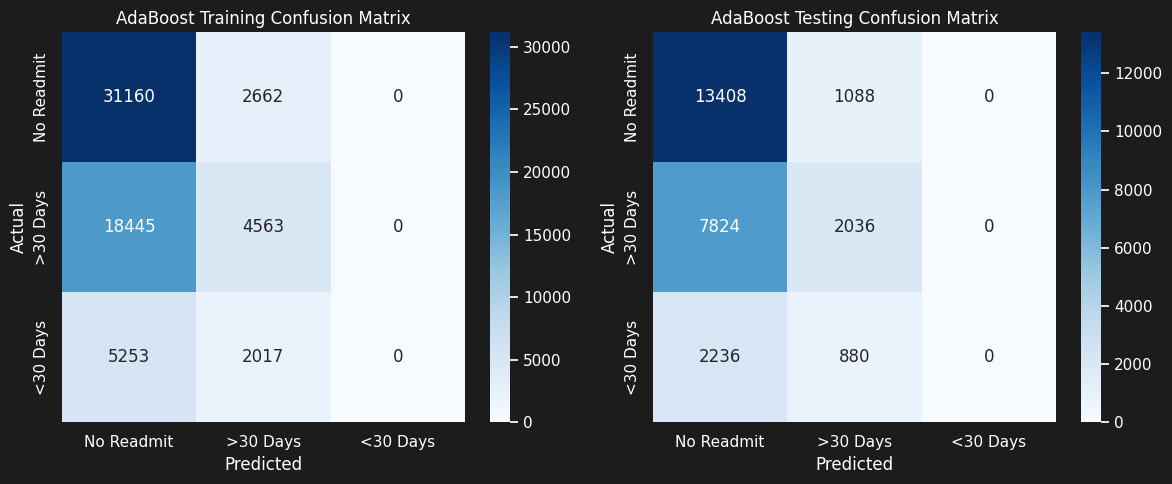

In [48]:
CLASS_NAMES = ['No Readmit', '>30 Days', '<30 Days']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, (X_eval, y_eval)) in zip(axes, [
    ('Training', (X_train_scaled, y_train)),
    ('Testing',  (X_test_scaled,  y_test))
]):
    cm = confusion_matrix(y_eval, best_ada.predict(X_eval))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'AdaBoost {name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_ADA.png')
plt.show()


In [49]:
for name, (X_eval, y_eval) in [('Training', (X_train_scaled, y_train)),
                                 ('Testing',  (X_test_scaled,  y_test))]:
    y_prob = best_ada.predict_proba(X_eval)
    auc = roc_auc_score(y_eval, y_prob, multi_class='ovr')
    print(f'AUC {name}: {auc:.3f}')


AUC Training: 0.612
AUC Testing: 0.617


## XAI Technique 1 — ICE Plots (Individual Conditional Expectation)

Top features for ICE: ['number_inpatient', 'discharge_group_Death', 'time_in_hospital', 'num_lab_procedures']


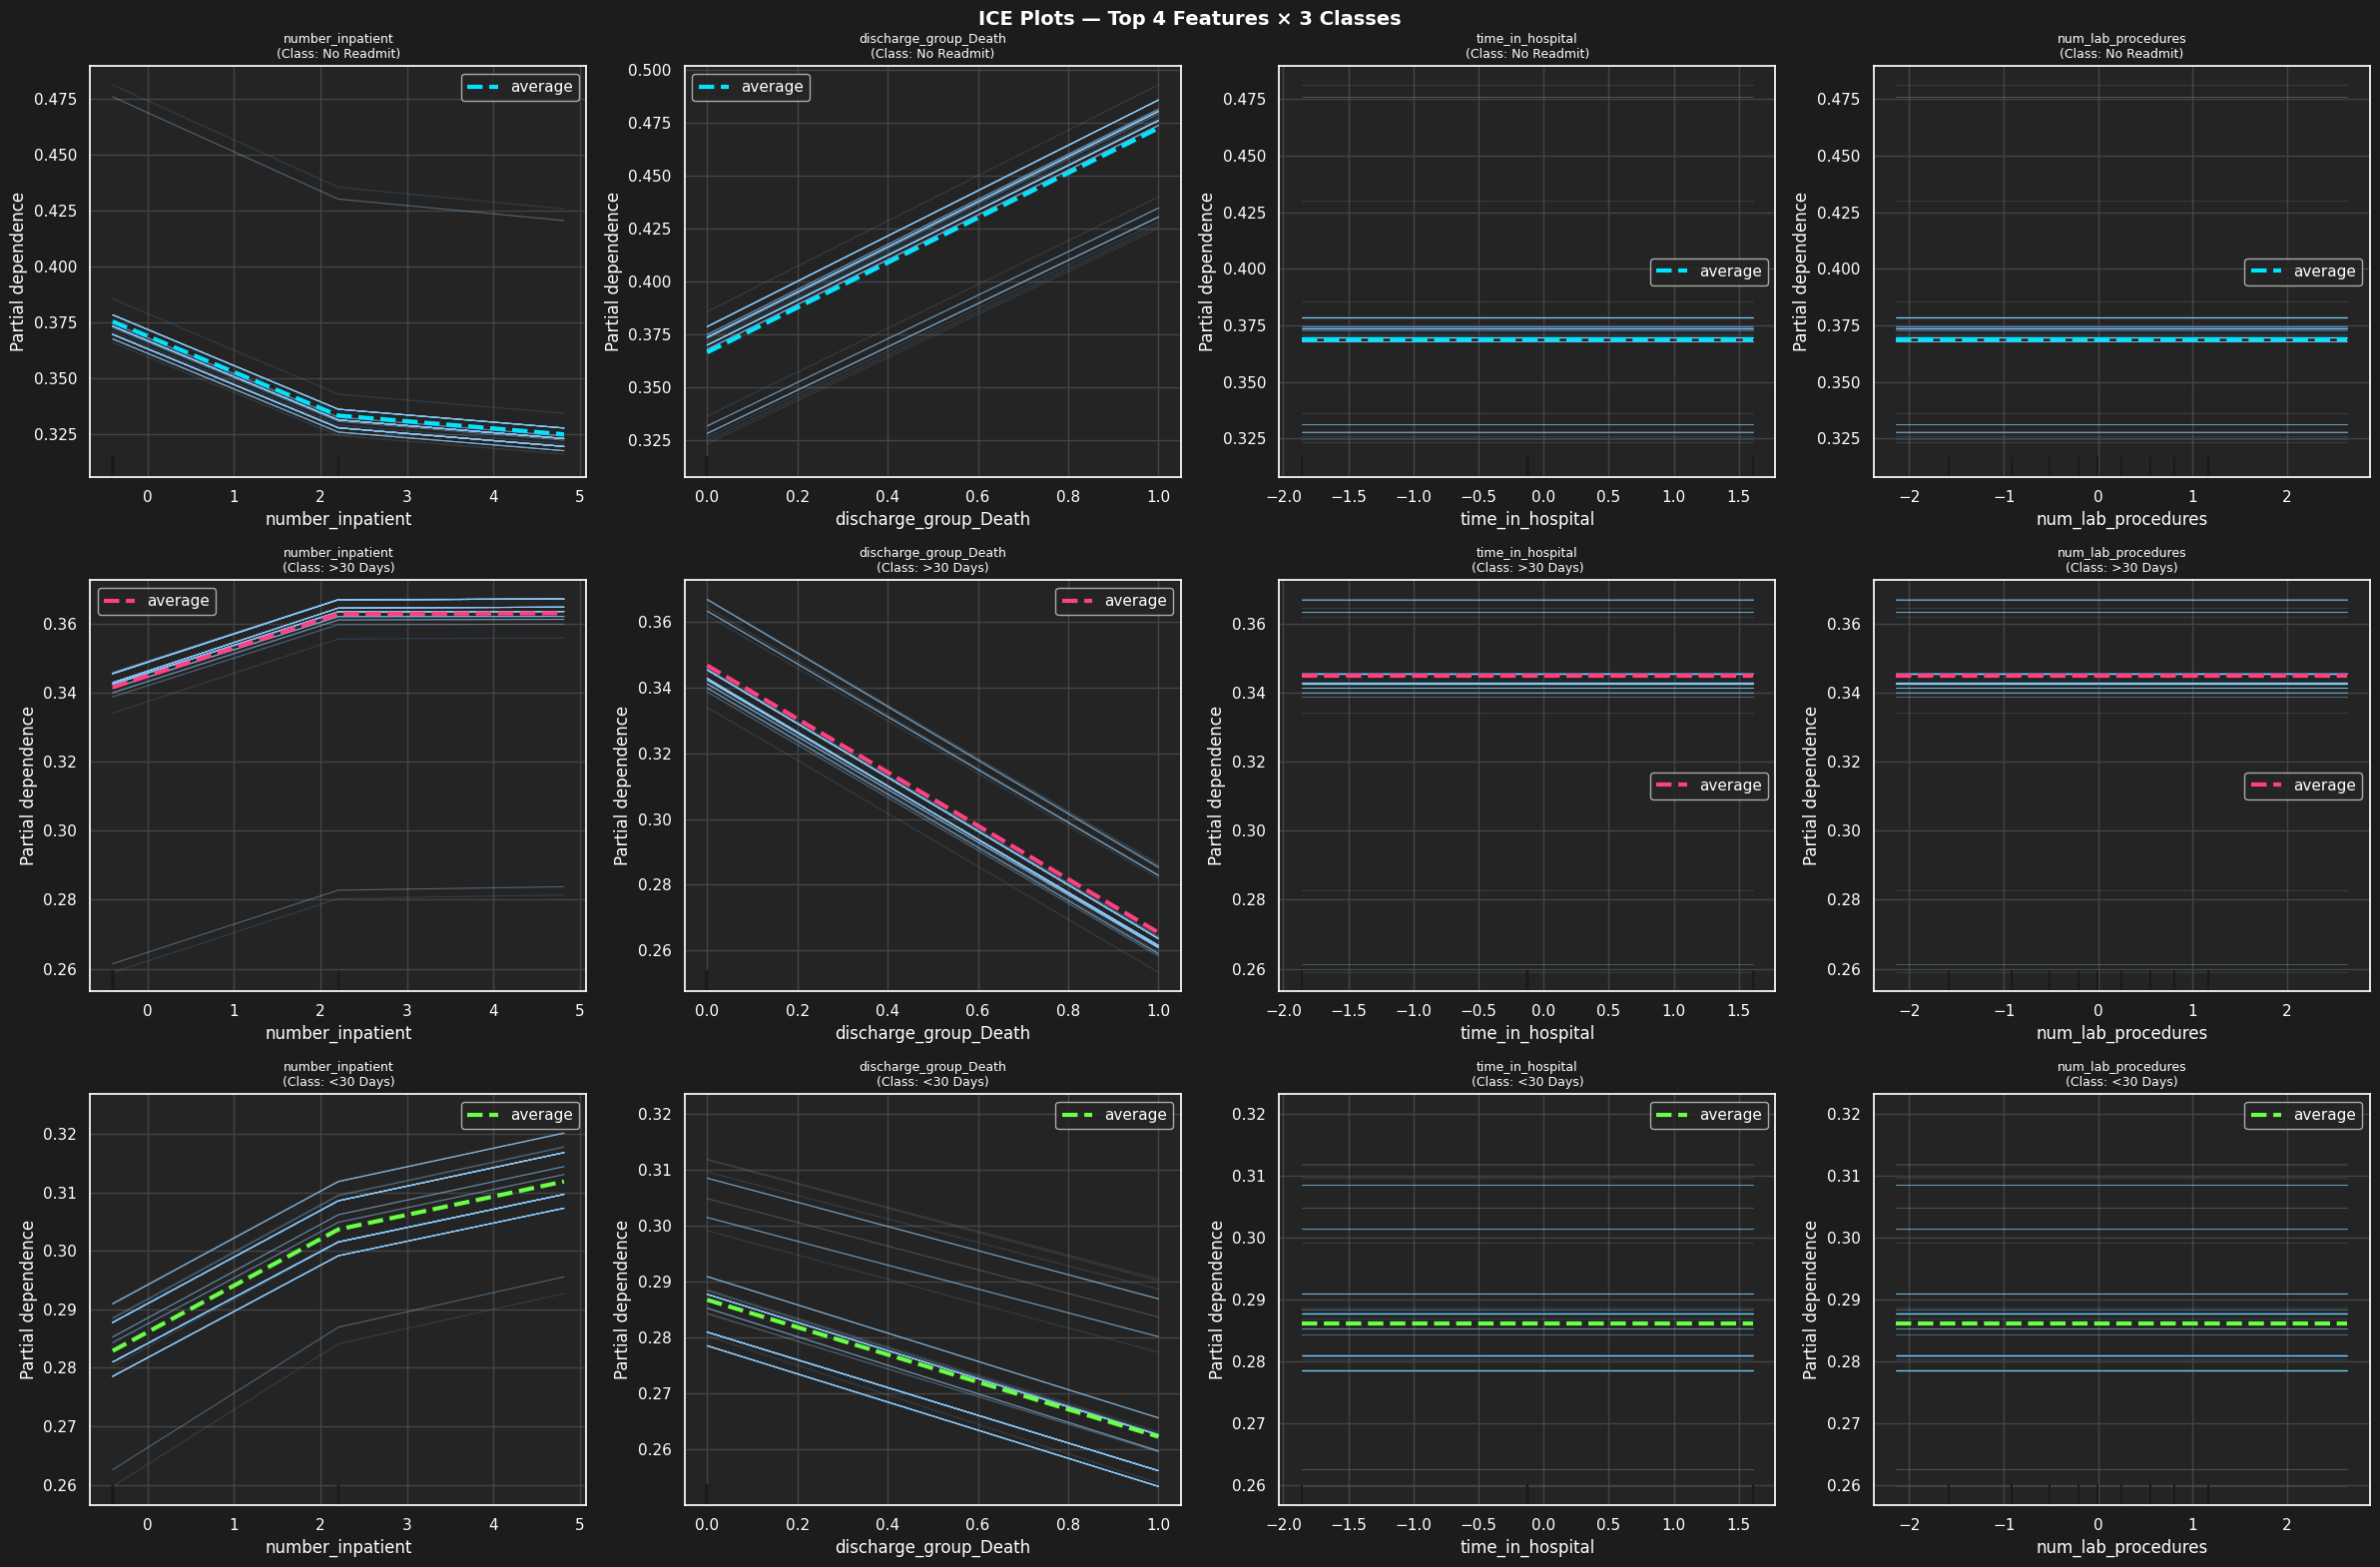

In [50]:
top_ice_features = list(
    pd.Series(
        permutation_importance(
            best_ada, X_test_scaled, y_test,
            n_repeats=5, scoring='accuracy', random_state=42, n_jobs=-1
        ).importances_mean,
        index=X_test_scaled.columns
    ).sort_values(ascending=False).head(4).index
)
print('Top features for ICE:', top_ice_features)

ice_sample = X_train_scaled.sample(1000, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(24, 16))
fig.suptitle('ICE Plots — Top 4 Features × 3 Classes',
             fontsize=14, fontweight='bold')

for col_idx, feature in enumerate(top_ice_features):
    for row_idx, cls_idx in enumerate(range(3)):
        ax = axes[row_idx][col_idx]
        disp = PartialDependenceDisplay.from_estimator(
            best_ada, ice_sample,
            features=[feature],
            target=cls_idx,
            kind='both',
            subsample=200,
            ax=ax,
            ice_lines_kw={'color': '#90caf9', 'alpha': 0.15, 'lw': 0.8},
            pd_line_kw={'color': ['#00e5ff','#ff4081','#69ff47'][cls_idx],
                        'lw': 3, 'linestyle': '--'},
            random_state=42
        )
        ax.set_title(f'{feature}\n(Class: {CLASS_NAMES[cls_idx]})', fontsize=9)
        ax.set_ylabel('Predicted probability', fontsize=8)

plt.tight_layout()
plt.savefig('ice_plots_ADA.png', dpi=100, bbox_inches='tight')
plt.show()


## XAI Technique 2 — PDP (Partial Dependence Plots)

Top features for PDP: ['number_inpatient', 'discharge_group_Death', 'time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient']


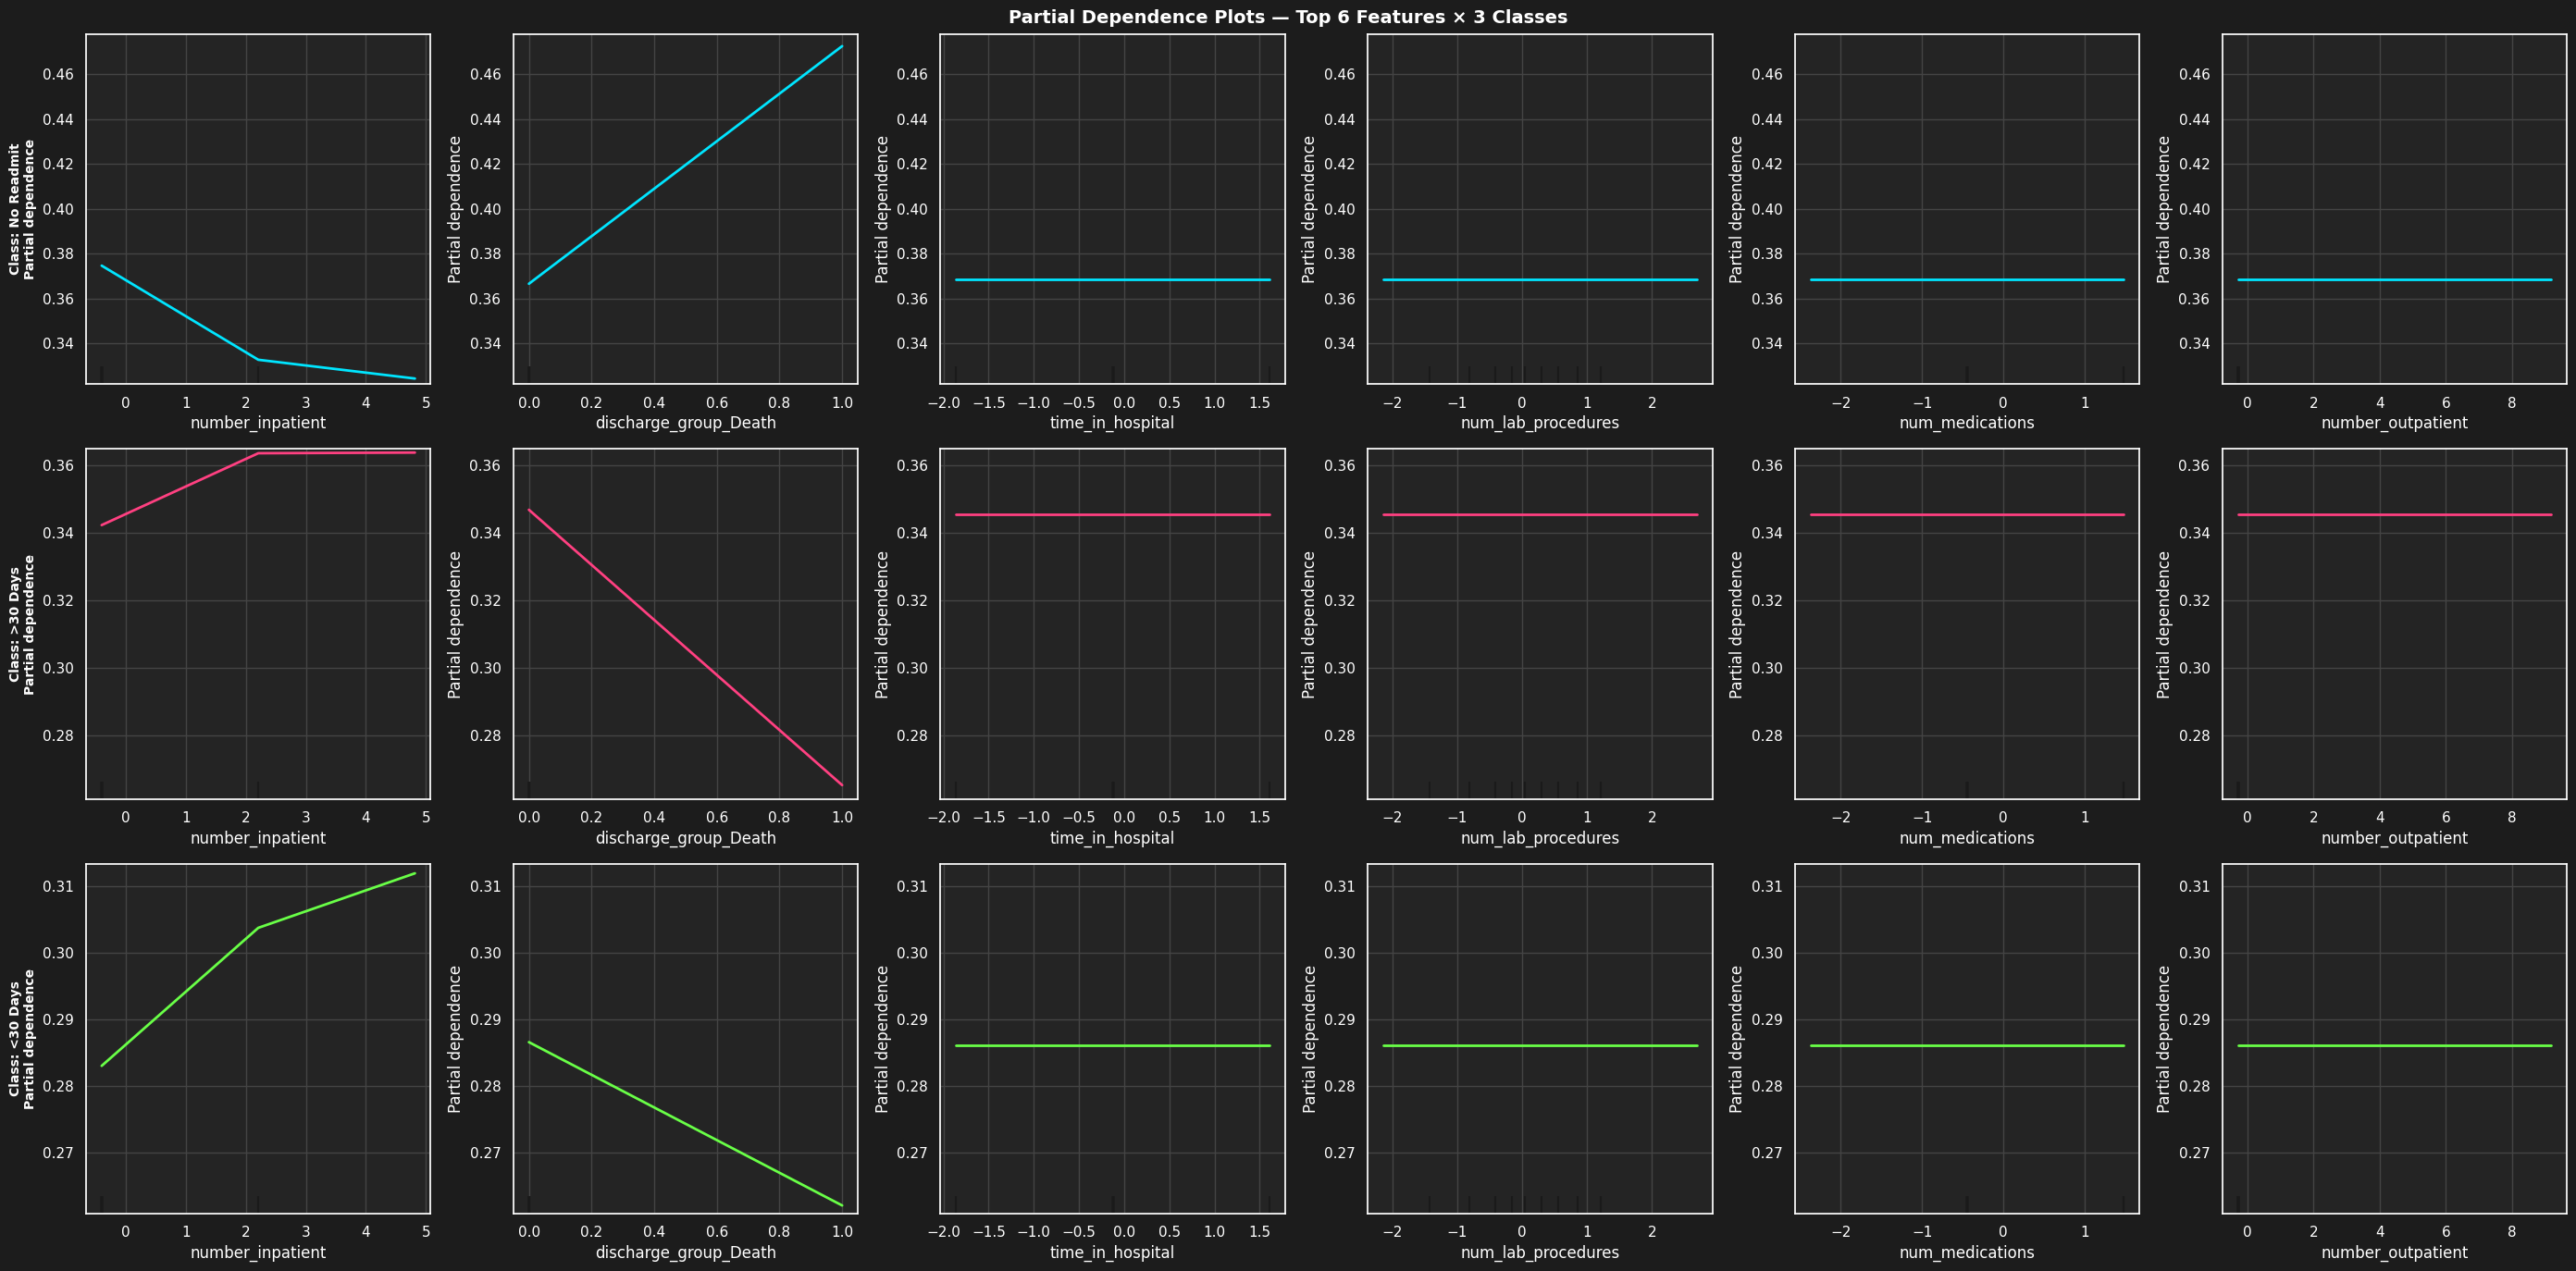

In [58]:
perm_quick = permutation_importance(
    best_ada, X_test_scaled, y_test,
    n_repeats=5, scoring='accuracy', random_state=42, n_jobs=-1
)
top_pdp_features = list(
    pd.Series(perm_quick.importances_mean, index=X_test_scaled.columns)
    .sort_values(ascending=False).head(6).index
)
print('Top features for PDP:', top_pdp_features)

pdp_sample = X_train_scaled.sample(5000, random_state=42)

fig, axes = plt.subplots(3, 6, figsize=(28, 14))
fig.suptitle('Partial Dependence Plots — Top 6 Features × 3 Classes',
             fontsize=14, fontweight='bold')

for row, cls_idx in enumerate(range(3)):
    PartialDependenceDisplay.from_estimator(
        best_ada, pdp_sample,
        features=top_pdp_features,
        target=cls_idx,
        kind='average',
        n_cols=6,
        ax=axes[row],
        line_kw={'color': ['#00e5ff','#ff4081','#69ff47'][cls_idx], 'lw': 2},
        subsample=0.5, random_state=42
    )
    axes[row][0].set_ylabel(
        f'Class: {CLASS_NAMES[cls_idx]}\nPartial dependence',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('pdp_ADA.png', dpi=100, bbox_inches='tight')
plt.show()


## XAI Technique 3 — LIME (Local Interpretable Model-Agnostic Explanations)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

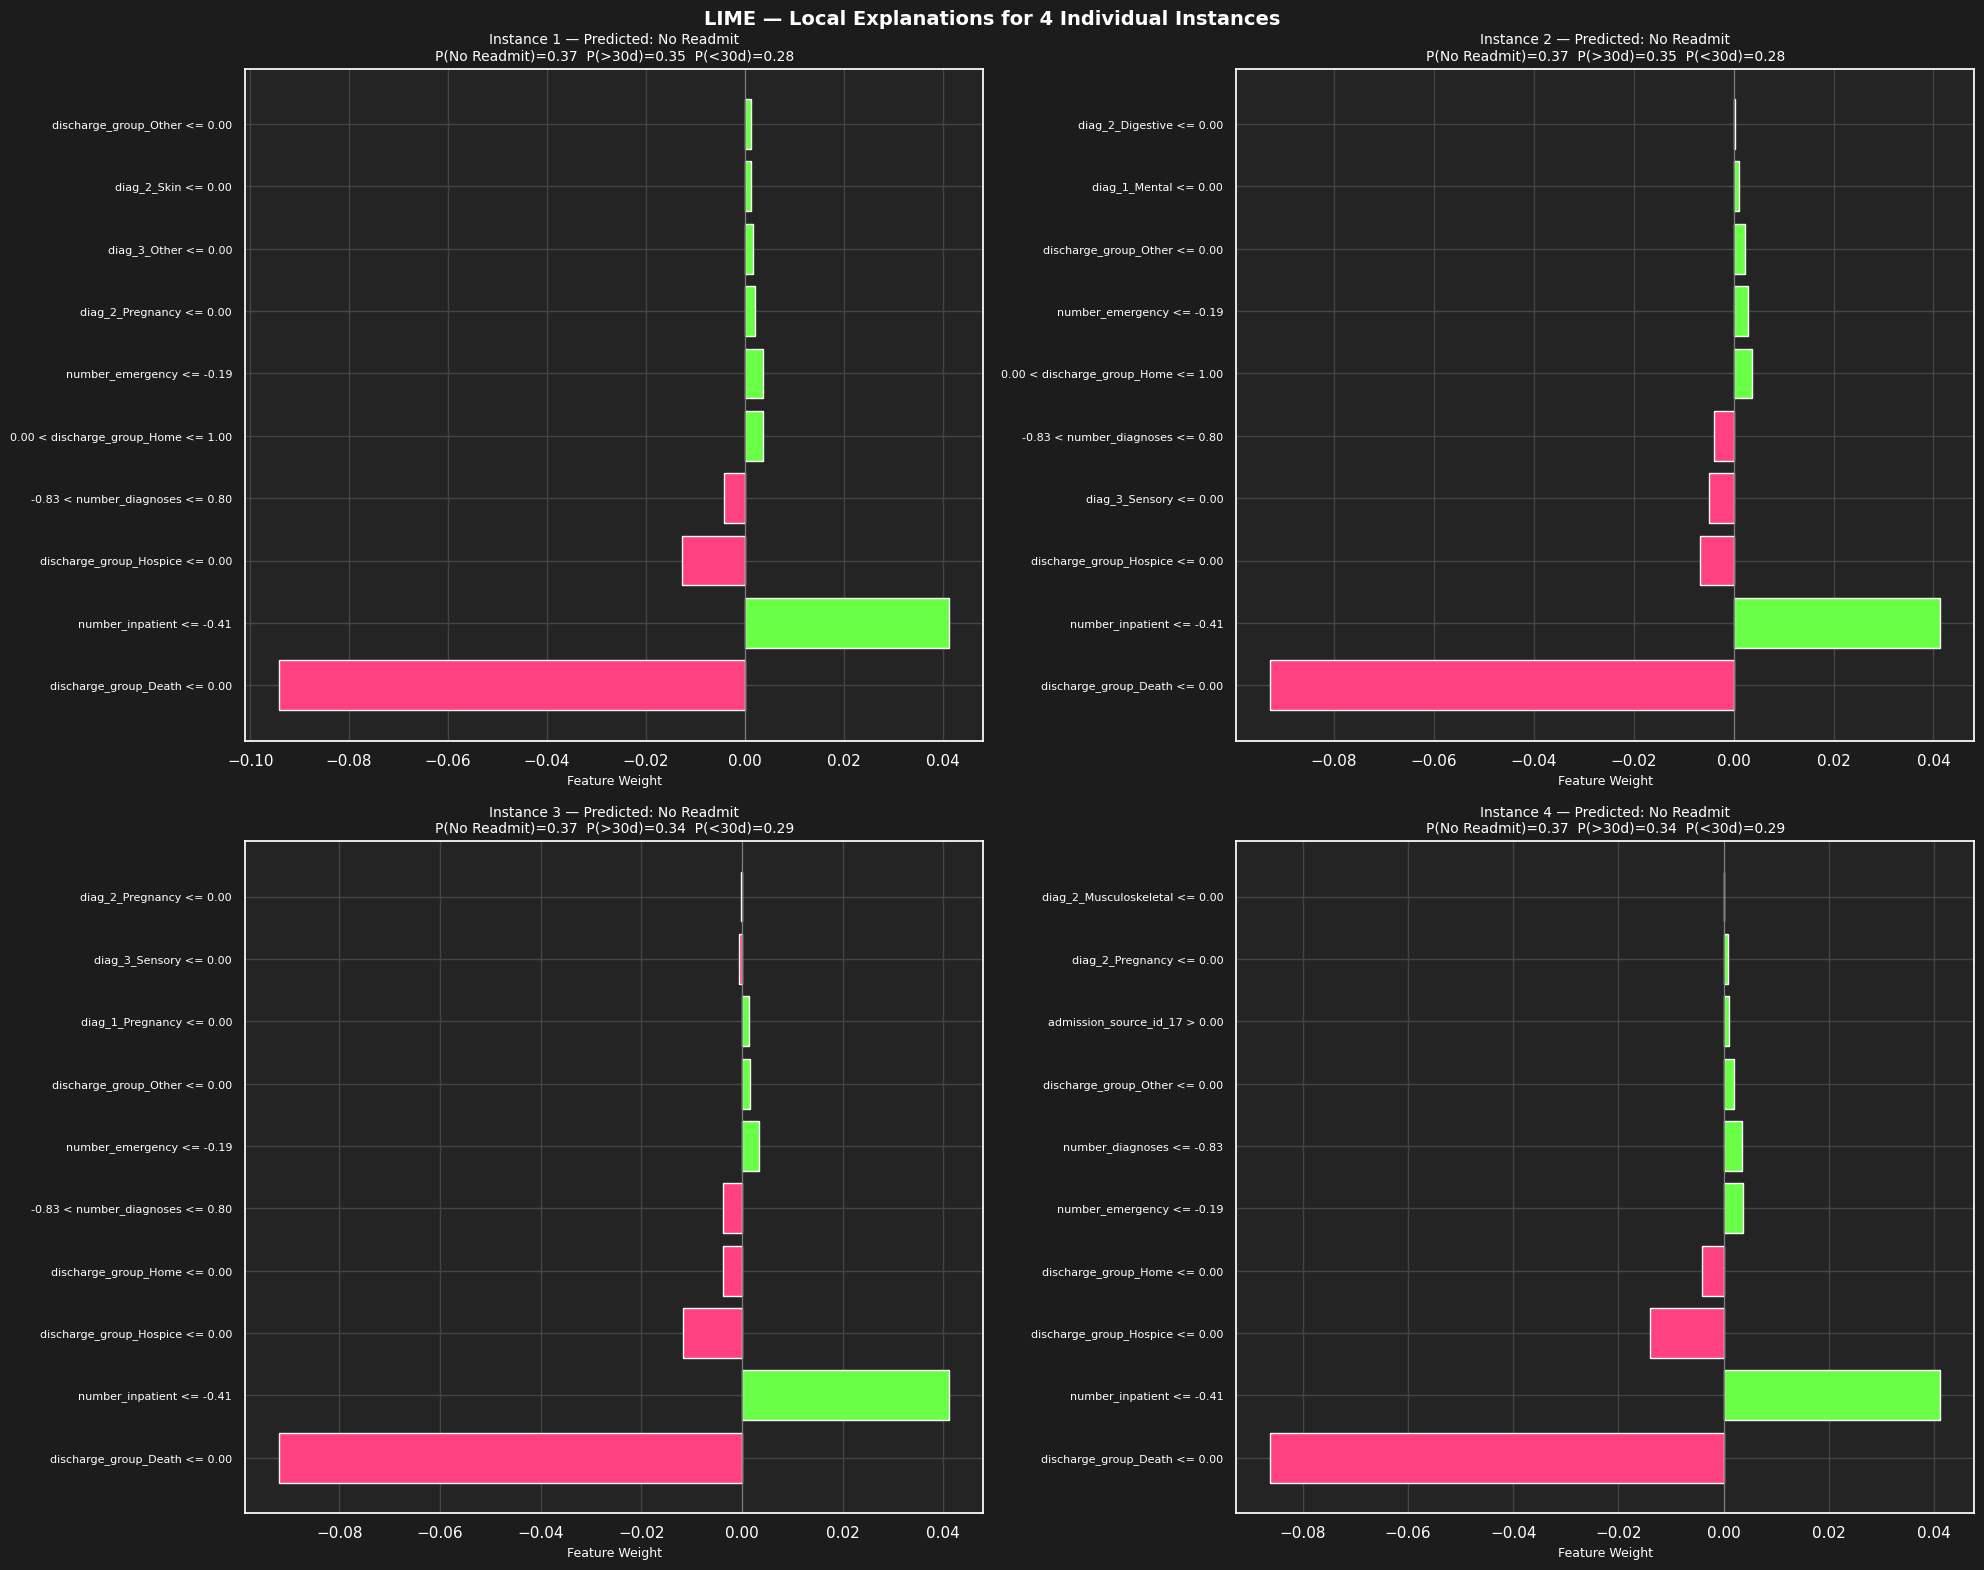

In [56]:


lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = np.array(X_train_scaled),
    feature_names         = X_train_scaled.columns.tolist(),
    class_names           = CLASS_NAMES,
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

y_pred_lime = best_ada.predict(X_test_scaled)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('LIME — Local Explanations for 4 Individual Instances',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    instance = X_test_scaled.iloc[i].values
    pred_cls = int(y_pred_lime[i])

    exp = lime_explainer.explain_instance(
        instance,
        best_ada.predict_proba,
        num_features=10,
        num_samples=500,
        top_labels=1
    )

    label        = list(exp.as_map().keys())[0]
    feat_weights = exp.as_list(label=label)
    features     = [fw[0] for fw in feat_weights]
    weights      = [fw[1] for fw in feat_weights]
    colors       = ['#69ff47' if w > 0 else '#ff4081' for w in weights]

    ax.barh(range(len(features)), weights, color=colors)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.axvline(x=0, color='grey', lw=0.8)
    probas = best_ada.predict_proba([instance])[0]
    ax.set_title(
        f'Instance {i+1} — Predicted: {CLASS_NAMES[pred_cls]}\n'
        f'P(No Readmit)={probas[0]:.2f}  P(>30d)={probas[1]:.2f}  P(<30d)={probas[2]:.2f}',
        fontsize=10
    )
    ax.set_xlabel('Feature Weight', fontsize=9)

plt.tight_layout()
plt.savefig('lime_ADA.png', dpi=120, bbox_inches='tight')
plt.show()


## XAI Technique 4 — Permutation Importance

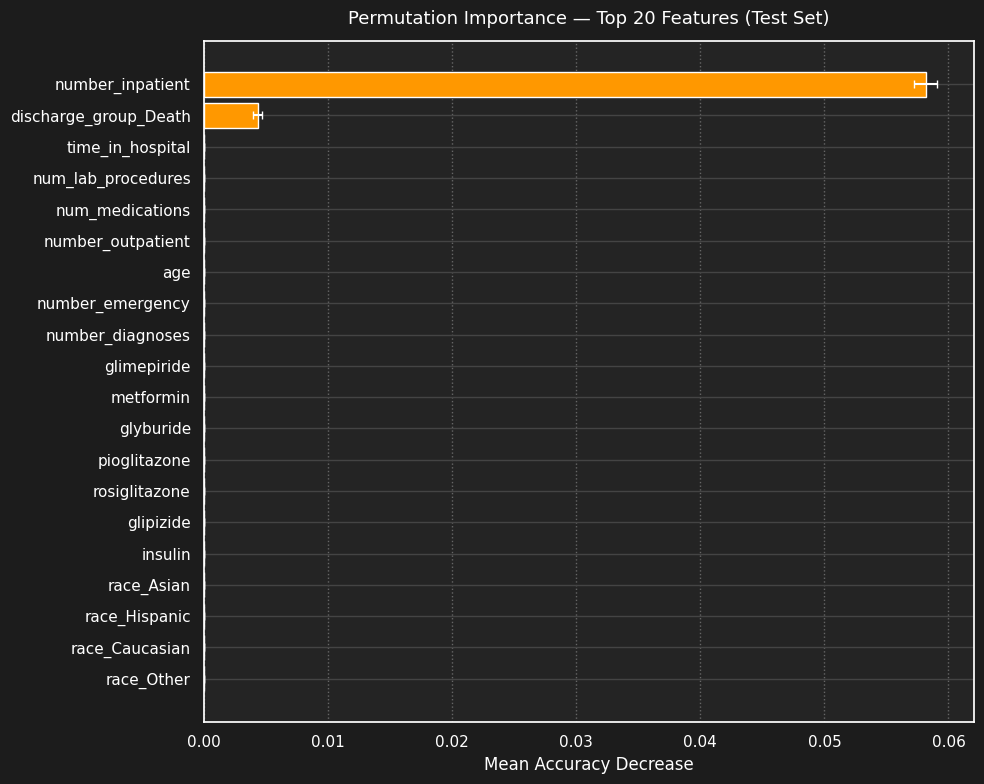

              feature  importance_mean  importance_std
     number_inpatient         0.058161        0.000940
discharge_group_Death         0.004310        0.000371
     time_in_hospital         0.000000        0.000000
   num_lab_procedures         0.000000        0.000000
      num_medications         0.000000        0.000000
    number_outpatient         0.000000        0.000000
                  age         0.000000        0.000000
     number_emergency         0.000000        0.000000
     number_diagnoses         0.000000        0.000000
          glimepiride         0.000000        0.000000


In [59]:
perm_result = permutation_importance(
    best_ada, X_test_scaled, y_test,
    n_repeats    = 10,
    scoring      = 'accuracy',
    random_state = 42,
    n_jobs       = -1
)

perm_df = pd.DataFrame({
    'feature':         X_test_scaled.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#242424')
ax.barh(
    perm_df['feature'][::-1],
    perm_df['importance_mean'][::-1],
    xerr    = perm_df['importance_std'][::-1],
    color   = '#ff9800',
    ecolor  = 'white',
    capsize = 3
)
ax.set_title('Permutation Importance — Top 20 Features (Test Set)',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Mean Accuracy Decrease', color='white')
ax.tick_params(colors='white')
ax.grid(True, linestyle=':', alpha=0.3, color='white', axis='x')
plt.tight_layout()
plt.savefig('permutation_importance_ADA.png', facecolor='#1c1c1c', dpi=120)
plt.show()

print(perm_df[['feature','importance_mean','importance_std']].head(10).to_string(index=False))
